<a href="https://colab.research.google.com/github/MightyJazz1012/SoftwareTech1-weeklyActivities/blob/main/ST1_Task1_1_7_u3324128.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import matplotlib
import keras
print(matplotlib.__version__)
print(keras.__version__)


3.10.0
3.13.2


<class 'PIL.JpegImagePlugin.JpegImageFile'>
JPEG
RGB
(1920, 2879)


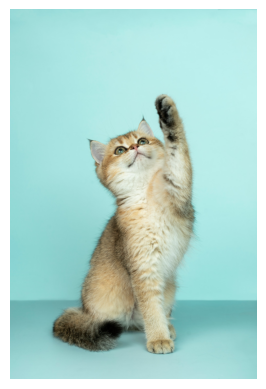

In [8]:
import matplotlib.pyplot as plt
# example of loading an image with the Keras API
from keras.preprocessing.image import load_img
# load the image
img_path = '/content/drive/MyDrive/cat.jpg'
img = load_img(img_path)
# report details about the image
print(type(img))
print(img.format)
print(img.mode)
print(img.size)
# show the image using matplotlib
plt.imshow(img)
plt.axis('off') # Turn off axis labels
plt.show()

In [10]:
from keras.preprocessing.image import load_img
from keras.preprocessing.image import img_to_array
from keras.preprocessing.image import array_to_img
# load the image
img_path = '/content/drive/MyDrive/cat.jpg'
img = load_img(img_path)
print(type(img))
# convert to numpy array
img_array = img_to_array(img)
print(img_array.dtype)
print(img_array.shape)
# convert back to image
img_pil = array_to_img(img_array)
print(type(img))

<class 'PIL.JpegImagePlugin.JpegImageFile'>
float32
(2879, 1920, 3)
<class 'PIL.JpegImagePlugin.JpegImageFile'>


<class 'PIL.Image.Image'>
None
RGB
(1920, 2879)


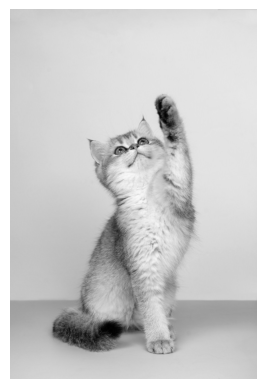

In [3]:
import matplotlib.pyplot as plt
import os
# example of saving an image with the Keras API
from keras.preprocessing.image import load_img
from keras.preprocessing.image import save_img
from keras.preprocessing.image import img_to_array
# load image as as grayscale
img_path = '/content/drive/MyDrive/cat.jpg'
img = load_img(img_path, color_mode='grayscale')
# convert image to a numpy array
img_array = img_to_array(img)
# save the image with a new filename
save_path_dir = '/content/drive/MyDrive/ST1 Colab'
save_filename = 'bondi_beach_grayscale.jpg'
full_save_path = os.path.join(save_path_dir, save_filename)
save_img(full_save_path, img_array)
# load the image to confirm it was saved correctly
img = load_img(full_save_path)
print(type(img))
print(img.format)
print(img.mode)
print(img.size)
# show the image using matplotlib
plt.imshow(img)
plt.axis('off') # Turn off axis labels
plt.show()

In [4]:
# load and summarize the MNIST dataset
from keras.datasets import mnist
# load dataset
(train_images, train_labels), (test_images,
test_labels) = mnist.load_data()
# summarize dataset shape
print('Train', train_images.shape,
train_labels.shape)
print('Test', (test_images.shape,
test_labels.shape))
# summarize pixel values
print('Train', train_images.min(),
train_images.max(), train_images.mean(),
train_images.std())
print('Train', test_images.min(),
test_images.max(), test_images.mean(),
test_images.std())

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train (60000, 28, 28) (60000,)
Test ((10000, 28, 28), (10000,))
Train 0 255 33.318421449829934 78.56748998339798
Train 0 255 33.791224489795916 79.17246322228644


In [5]:
# example of normalizing an image dataset (MNIST)
from keras.datasets import mnist
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# load dataset
(trainX, trainY), (testX, testY) = mnist.load_data()
# reshape dataset to have a single channel
width, height, channels = trainX.shape[1], trainX.shape[2], 1
trainX = trainX.reshape((trainX.shape[0], width, height, channels))
testX = testX.reshape((testX.shape[0], width, height, channels))
# confirm scale of pixels
print('Train min=%.3f, max=%.3f' % (trainX.min(), trainX.max()))
print('Test min=%.3f, max=%.3f' % (testX.min(), testX.max()))
# create generator (1.0/255.0 = 0.003921568627451)
datagen = ImageDataGenerator(rescale=1.0/255.0)
# Note: there is no need to fit the generator in this case
# prepare a iterators to scale images
train_iterator = datagen.flow(trainX, trainY, batch_size=64)
test_iterator = datagen.flow(testX, testY, batch_size=64)
print('Batches train=%d, test=%d' % (len(train_iterator),
len(test_iterator)))
# confirm the scaling works
batchX, batchy = next(train_iterator)
print('Batch shape=%s, min=%.3f, max=%.3f' % (batchX.shape,
batchX.min(), batchX.max()))

Train min=0.000, max=255.000
Test min=0.000, max=255.000
Batches train=938, test=157
Batch shape=(64, 28, 28, 1), min=0.000, max=1.000


In [7]:
from keras.datasets import mnist
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# load dataset
(trainX, trainy), (testX, testy) = mnist.load_data()
# reshape dataset to have a single channel
width, height, channels = trainX.shape[1], trainX.shape[2], 1
trainX = trainX.reshape((trainX.shape[0], width, height,
channels))
testX = testX.reshape((testX.shape[0], width, height,
channels))
# report per-image mean
print('Means train=%.3f, test=%.3f' % (trainX.mean(),
testX.mean()))
# create generator that centers pixel values
datagen = ImageDataGenerator(featurewise_center=True)
# calculate the mean on the training dataset
datagen.fit(trainX)
print('Data Generator Mean: %.3f' % datagen.mean.item())
# demonstrate effect on a single batch of samples
iterator = datagen.flow(trainX, trainy, batch_size=64)
# get a batch
batchX, batchy = next(iterator)
# mean pixel value in the batch
print(batchX.shape, batchX.mean())
# demonstrate effect on entire training dataset
iterator = datagen.flow(trainX, trainy,
batch_size=len(trainX), shuffle=False)
# get a batch
batchX, batchy = next(iterator)
# mean pixel value in the batch
print(batchX.shape, batchX.mean())


Means train=33.318, test=33.791
Data Generator Mean: 33.318
(64, 28, 28, 1) 0.7592581
(60000, 28, 28, 1) -1.9512918e-05


In [8]:
from keras.datasets import mnist
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# load dataset
(trainX, trainy), (testX, testy) = mnist.load_data()
# reshape dataset to have a single channel
width, height, channels = trainX.shape[1], trainX.shape[2], 1
trainX = trainX.reshape((trainX.shape[0], width, height, channels))
testX = testX.reshape((testX.shape[0], width, height, channels))
# report pixel means and standard deviations
print('Statistics train=%.3f (%.3f), test=%.3f (%.3f)' % (trainX.mean(), trainX.std(),
testX.mean(), testX.std()))
# create generator that centers pixel values
datagen = ImageDataGenerator(featurewise_center=True,
featurewise_std_normalization=True)
# calculate the mean on the training dataset
datagen.fit(trainX)
print('Data Generator mean=%.3f, std=%.3f' % (datagen.mean.item(),
datagen.std.item()))
# demonstrate effect on a single batch of samples
iterator = datagen.flow(trainX, trainy, batch_size=64)
# get a batch
batchX, batchy = next(iterator)
# pixel stats in the batch
print(batchX.shape, batchX.mean(), batchX.std())
# demonstrate effect on entire training dataset
iterator = datagen.flow(trainX, trainy, batch_size=len(trainX), shuffle=False)
# get a batch
batchX, batchy = next(iterator)
# pixel stats in the batch
print(batchX.shape, batchX.mean(), batchX.std())


Statistics train=33.318 (78.567), test=33.791 (79.172)
Data Generator mean=33.318, std=78.567
(64, 28, 28, 1) 0.03881095 1.0365604
(60000, 28, 28, 1) -3.4560264e-07 0.9999998
